In [55]:
import pandas as pd

df = pd.read_csv("/home/ki/Downloads/database_train.csv")
# df = pd.read_csv("/run/media/ki/data/datasets/GTSRB/Train.csv")


class_to_name_map = {}

with open("/run/media/ki/data/datasets/GTSRB/labels.txt", "r") as f:
    for n, line in enumerate(f):
        class_to_name_map[n] = line.strip().strip("'")


class_to_name_map

{0: 'speed limit 20',
 1: 'speed limit 30',
 2: 'speed limit 50',
 3: 'speed limit 60',
 4: 'speed limit 70',
 5: 'speed limit 80',
 6: 'restriction ends 80',
 7: 'speed limit 100',
 8: 'speed limit 120',
 9: 'no overtaking',
 10: 'no overtaking (trucks)',
 11: 'priority at next intersection',
 12: 'priority road',
 13: 'give way',
 14: 'stop',
 15: 'no traffic both ways',
 16: 'no trucks',
 17: 'no entry',
 18: 'danger',
 19: 'bend left',
 20: 'bend right',
 21: 'bend',
 22: 'uneven road',
 23: 'slippery road',
 24: 'road narrows',
 25: 'construction',
 26: 'traffic signal',
 27: 'pedestrian crossing',
 28: 'school crossing',
 29: 'cycles crossing',
 30: 'snow',
 31: 'animals',
 32: 'restriction ends',
 33: 'go right',
 34: 'go left',
 35: 'go straight',
 36: 'go right or straight',
 37: 'go left or straight',
 38: 'keep right',
 39: 'keep left',
 40: 'roundabout',
 41: 'restriction ends (overtaking)',
 42: 'restriction ends (overtaking (trucks))'}

In [ ]:
df_meta = pd.read_csv("/run/media/ki/data/datasets/GTSRB/Meta.csv")

df_meta

In [ ]:
shape_to_name = {
    0: "triangle",
    1: "circle",
    2: "square",
    3: "octagon",
    4: "inv-triange",
}

color_to_name = {
    0: "red",
    1: "blue",
    2: "yellow",
    3: "white",
}

mymap = {}

for i, row in df_meta.iterrows():
    mymap[row.ClassId] = (row.ShapeId, row.ColorId)

In [ ]:
df["ClassName"] = df["ClassId"].apply(lambda x: class_to_name_map.get(x))
df["ShapeId"] = df["ClassId"].apply(lambda x: mymap.get(x)[0])
df["ColorId"] = df["ClassId"].apply(lambda x: mymap.get(x)[1])
df["ShapeName"] = df["ShapeId"].apply(lambda x: shape_to_name.get(x))
df["ColorName"] = df["ColorId"].apply(lambda x: color_to_name.get(x))

In [ ]:
df

In [ ]:
del df["ShapeId"]
del df["ColorId"]
del df["ClassId"]
# del df["Roi.X1"]
# del df["Roi.X2"]
# del df["Roi.Y1"]
# del df["Roi.Y2"]
# del df["Width"]
# del df["Height"]
del df["Unnamed: 0"]
del df["Path"]

In [ ]:
# df.loc[df["ClassName"] == "stop", "ShapeName"] = "octagon"

In [ ]:
df[df["ClassName"] == "stop"]

In [ ]:
print(df.head().to_string())

In [ ]:
df = df.rename(
    columns={
        "ColorName": "Color",
        "ClassName": "Class",
        "ShapeName": "Shape",
    }
)

In [ ]:
df_encoded = pd.get_dummies(df).rename(columns=lambda x: x.replace("_", " "))
df_encoded = df_encoded.replace({True: 1, False: -1})
corr = df_encoded.corr()

In [ ]:
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
# cmap = sb.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
# sb.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
#             square=True, linewidths=.5, cbar_kws={"shrink": .5})

g = sb.clustermap(
    corr,
    cmap="coolwarm",
    # cmap=cmap,
    # annot=True,
    # square=True,
    vmin=-1.0,
    vmax=1.0,
    linewidths=0.5,
    center=0,
    figsize=(15, 15),
    cbar_pos=(0.02, 0.32, 0.03, 0.2),
    dendrogram_ratio=(0.1, 0.2),
)

g.ax_row_dendrogram.remove()
# plt.tight_layout(pad=0)
plt.savefig("/home/ki/correlations-gtsrb.pdf", bbox_inches="tight")

# Calculate effect size

In [3]:
import pandas as pd

results = pd.read_csv(
    "/home/ki/projects/work/mln-ood/gtsrb/outputs/2025-03-25/16-07-55/results.csv"
)

In [4]:
print(list(results.Method.unique()))

['ViM', 'DICE', 'Mahalanobis', 'ReAct', 'SHE', 'MSP', 'Entropy', 'EBO', 'Ensemble', 'Logic', 'MLN', 'Logic+Ensemble', 'MLN+Ensemble', 'MLN+ViM', 'MLN+EBO', 'MLN+DICE', 'MLN+Mahalanobis', 'MLN+MSP', 'MLN+ReAct', 'MLN+SHE']


In [7]:
a = results[results["Method"] == "Logic+Ensemble"]
c1 = a[["Seed", "AUROC"]].groupby("Seed").mean().values

b = results[results["Method"] == "Ensemble"]
c0 = b[["Seed", "AUROC"]].groupby("Seed").mean().values

b = results[results["Method"] == "MLN+Ensemble"]
c2 = b[["Seed", "AUROC"]].groupby("Seed").mean().values

In [11]:
from numpy import mean, std  # version >= 1.7.1
from math import sqrt
import numpy as np


def cohen_d(x, y):
    return (mean(x) - mean(y)) / sqrt((std(x, ddof=1) ** 2 + std(y, ddof=1) ** 2) / 2.0)


print(cohen_d(c2, c0))
print(cohen_d(c1, c0))

print(cohen_d(c2, c1))

print(np.mean(c0))
print(np.mean(c1))
print(np.mean(c2))

1.2727818042939656
0.7517811388357079
0.5620828302544454
99.8031409829855
99.8539350181818
99.8826888948679


In [13]:
from scipy.stats import ttest_rel, ttest_ind

print(ttest_ind(c2, c0))


print(ttest_rel(c1, c0))
print(ttest_ind(c1, c0))

print(ttest_rel(c1, c2))
print(ttest_ind(c1, c2))

TtestResult(statistic=array([2.84602663]), pvalue=array([0.01072301]), df=array([18.]))
TtestResult(statistic=array([1.74877799]), pvalue=array([0.11426319]), df=array([9]))
TtestResult(statistic=array([1.68103373]), pvalue=array([0.11002576]), df=array([18.]))
TtestResult(statistic=array([-5.25996802]), pvalue=array([0.00052076]), df=array([9]))
TtestResult(statistic=array([-1.25685542]), pvalue=array([0.22487163]), df=array([18.]))


/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ki/.local/sh

,AUROC,Method
0,99.435591,Ensemble
1,99.366624,Ensemble
2,98.907367,Ensemble
3,99.434973,Ensemble
4,99.341518,Ensemble
5,99.036900,Ensemble
6,99.280144,Ensemble
7,99.339231,Ensemble
8,99.289031,Ensemble
9,99.362826,Ensemble


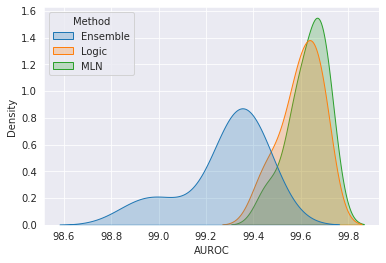

In [57]:
import matplotlib.pyplot as plt
import seaborn as sb

data = []
data += [{"AUROC": v[0], "Method": "Ensemble"} for v in c0]
data += [{"AUROC": v[0], "Method": "Logic"} for v in c1]
data += [{"AUROC": v[0], "Method": "MLN"} for v in c2]

df = pd.DataFrame(data)

sb.kdeplot(df, x="AUROC", hue="Method", fill=True)
df
# plt.hist(c0)
# plt.hist(c1)

In [ ]:
from scipy.stats import normaltest

normaltest(c0)

In [ ]:
normaltest(c1)

In [ ]:
# small number of samples, use monte-carlo test

# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.monte_carlo_test.html#scipy.stats.monte_carlo_test

In [ ]:
import numpy as np
from scipy import stats
from scipy.stats import monte_carlo_test


def statistic(x, axis):
    return stats.skew(x, axis)


rng = np.random.default_rng()


rvs = lambda size: stats.norm.rvs(size=size, random_state=rng)
res = monte_carlo_test(c0, rvs, statistic, vectorized=True)
print(res.pvalue)

res = monte_carlo_test(c1, rvs, statistic, vectorized=True)
print(res.pvalue)
# x = stats.skewnorm.rvs(a=1, size=50, random_state=rng)
# statistic(c0, axis=0)

In [ ]:
fig, ax = plt.subplots()

ax.hist(res.null_distribution, bins=50)
ax.set_title("Monte Carlo distribution of test statistic")
ax.set_xlabel("Value of Statistic")
ax.set_ylabel("Frequency")
plt.show()

In [8]:
import pandas as pd
import re


# ReAct not there
desired_order = [
    "MSP",
    "EBO",
    "Entropy",
    "Mahalanobis",
    "ViM",
    "DICE",
    "Ensemble",
    "Logic",
    "Logic+Ensemble",
    "MLN+Ensemble",
    "Logic+Ensemble+",
    "MLN+",
    "MLN+Ensemble+",
]

#  "LLama2-7b", "LLama2-7b-kb", "Naive LLama2-7b", "Naive LLama2-7b-kb"


path = "outputs/2025-03-07/13-17-53/results-agg.pkl"

df = pd.read_pickle(path)


for metric in ["AUROC", "AUPR-IN", "AUPR-OUT", "FPR95TPR"]:
    df[(metric, "mean", "sem")] = df[(metric, "mean", "sem")].apply(
        lambda x: "$\pm {:.2f}$".format(x)
    )

reordered_df = df.reindex(desired_order)

s = reordered_df.to_latex(float_format="{:.3f}".format)
# s = s.replace("Logic", "Naïve Logic").replace("MLN-OOD-Untrained", "MLN-OOD (Untrained)")

s = re.sub(r"&", r"& & &", s, count=1)

print(s)

\begin{tabular}{lrlrlrlrl}
\toprule
 & & & \multicolumn{2}{r}{AUROC} & \multicolumn{2}{r}{AUPR-IN} & \multicolumn{2}{r}{AUPR-OUT} & \multicolumn{2}{r}{FPR95TPR} \\
 & \multicolumn{2}{r}{mean} & \multicolumn{2}{r}{mean} & \multicolumn{2}{r}{mean} & \multicolumn{2}{r}{mean} \\
 & mean & sem & mean & sem & mean & sem & mean & sem \\
Method &  &  &  &  &  &  &  &  \\
\midrule
MSP & 98.961 & $\pm 0.25$ & 99.043 & $\pm 0.30$ & 96.616 & $\pm 1.19$ & 3.041 & $\pm 0.81$ \\
EBO & 99.052 & $\pm 0.34$ & 98.845 & $\pm 0.39$ & 98.275 & $\pm 0.46$ & 3.576 & $\pm 1.80$ \\
Entropy & 99.111 & $\pm 0.25$ & 99.097 & $\pm 0.30$ & 97.671 & $\pm 0.75$ & 2.912 & $\pm 0.87$ \\
Mahalanobis & 99.228 & $\pm 0.08$ & 99.554 & $\pm 0.13$ & 94.667 & $\pm 2.31$ & 1.846 & $\pm 0.27$ \\
ViM & 99.469 & $\pm 0.08$ & 99.630 & $\pm 0.13$ & 97.305 & $\pm 1.18$ & 1.706 & $\pm 0.30$ \\
DICE & 99.039 & $\pm 0.35$ & 98.831 & $\pm 0.39$ & 98.242 & $\pm 0.47$ & 3.621 & $\pm 1.82$ \\
Ensemble & 99.803 & $\pm 0.03$ & 99.842 & $\pm 0

In [114]:
import torch
from os.path import join

root = "outputs/2024-07-18/15-37-37/"
logic_in = torch.load(join(root, "Textures-logic-in.pt"))
logic_ood = torch.load(join(root, "Textures-logic-ood.pt"))

naive_in = torch.load(join(root, "Textures-naive-in.pt"))
naive_ood = torch.load(join(root, "Textures-naive-ood.pt"))

ensemble_in = -torch.load(join(root, "Textures-ensemble-in.pt"))
ensemble_ood = -torch.load(join(root, "Textures-ensemble-ood.pt"))

In [115]:
torch.cat([logic_in, logic_ood]).shape

torch.Size([18270, 1])

/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ki/.local/sh

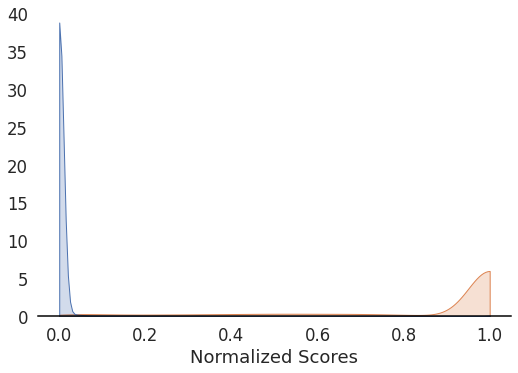

In [128]:
import seaborn as sb
import matplotlib.pyplot as plt


sb.set_context("paper")
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sb.set_theme(style="white", rc=custom_params, font_scale=1.5)

score_df = pd.DataFrame(
    {
        "Scores": torch.cat([logic_in, logic_ood]).squeeze().tolist(),
        "Labels": ["IN"] * len(logic_in) + ["OOD"] * len(logic_ood),
    }
)

# Normalize the scores to be in the range 0-1
min_score = score_df["Scores"].min()
max_score = score_df["Scores"].max()
score_df["normalized_scores"] = (score_df["Scores"] - min_score) / (
    max_score - min_score
)
plt.figure(figsize=(7, 5))
sb.kdeplot(
    data=score_df,
    x="normalized_scores",
    hue="Labels",
    common_norm=False,
    clip=[0, 1],
    fill=True,
    legend=False,
)
# plt.title("Distribution of Normalized Scores")
plt.xlabel("Normalized Scores")
plt.ylabel("")
# Customize the bottom line (x-axis) to be thick and black
ax = plt.gca()  # Get the current axis
ax.spines["bottom"].set_linewidth(1.5)  # Set the bottom spine's line width
ax.spines["bottom"].set_color("black")  # Set the bottom spine's color
plt.tight_layout(pad=0)
sb.despine(top=True, left=True, right=True, bottom=False)
plt.savefig("/home/ki/gtsrb-scores-logic-ood.pdf", bbox_inches="tight")

plt.show()

/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ki/.local/sh

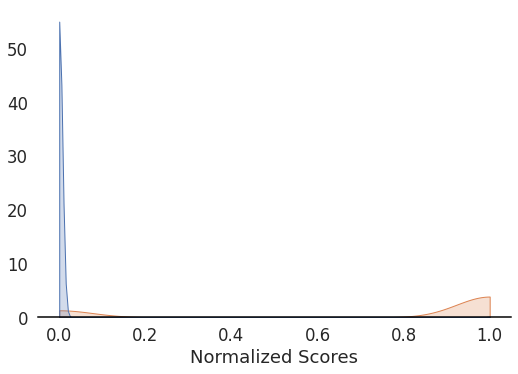

In [129]:
score_df = pd.DataFrame(
    {
        "Scores": torch.cat([naive_in, naive_ood]).squeeze().tolist(),
        "Labels": ["IN"] * len(naive_in) + ["OOD"] * len(naive_ood),
    }
)

# Normalize the scores to be in the range 0-1
min_score = score_df["Scores"].min()
max_score = score_df["Scores"].max()
score_df["normalized_scores"] = (score_df["Scores"] - min_score) / (
    max_score - min_score
)
plt.figure(figsize=(7, 5))
sb.kdeplot(
    data=score_df,
    x="normalized_scores",
    hue="Labels",
    common_norm=False,
    clip=[0, 1],
    fill=True,
    legend=False,
)
# plt.title("Distribution of Normalized Scores")
plt.xlabel("Normalized Scores")
plt.ylabel("")
# Customize the bottom line (x-axis) to be thick and black
ax = plt.gca()  # Get the current axis
ax.spines["bottom"].set_linewidth(1.5)  # Set the bottom spine's line width
ax.spines["bottom"].set_color("black")  # Set the bottom spine's color
plt.tight_layout(pad=0)
sb.despine(top=True, left=True, right=True, bottom=False)
plt.savefig("/home/ki/gtsrb-scores-naive.pdf", bbox_inches="tight")

plt.show()

/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ki/.local/sh

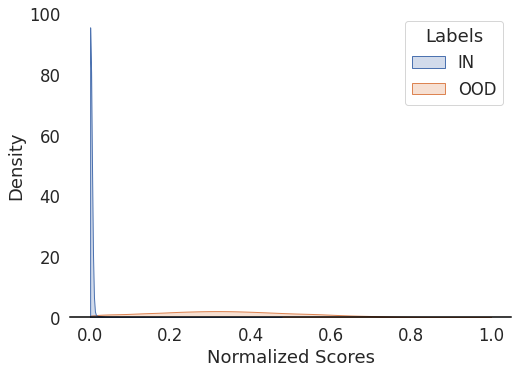

In [130]:
score_df = pd.DataFrame(
    {
        "Scores": torch.cat([ensemble_in, ensemble_ood]).squeeze().tolist(),
        "Labels": ["IN"] * len(ensemble_in) + ["OOD"] * len(ensemble_ood),
    }
)

# Normalize the scores to be in the range 0-1
min_score = score_df["Scores"].min()
max_score = score_df["Scores"].max()
score_df["normalized_scores"] = (score_df["Scores"] - min_score) / (
    max_score - min_score
)
plt.figure(figsize=(7, 5))
# sb.histplot(data=score_df, x="normalized_scores", hue="Labels", kde=True, bins=20, stat="probability", common_norm=False)
sb.kdeplot(
    data=score_df,
    x="normalized_scores",
    hue="Labels",
    common_norm=False,
    clip=[0, 1],
    fill=True,
)
# plt.title("Distribution of Normalized Scores")
plt.xlabel("Normalized Scores")
plt.ylabel("Density")
# Customize the bottom line (x-axis) to be thick and black
ax = plt.gca()  # Get the current axis
ax.spines["bottom"].set_linewidth(1.5)  # Set the bottom spine's line width
ax.spines["bottom"].set_color("black")  # Set the bottom spine's color
plt.tight_layout(pad=0)
sb.despine(top=True, left=True, right=True, bottom=False)
plt.savefig("/home/ki/gtsrb-scores-ensemble.pdf", bbox_inches="tight")

In [75]:
import torch

scores_vim_in = torch.load("outputs/2024-08-22/16-41-20/Textures-vim-in.pt").numpy()
scores_vim_val = torch.load("outputs/2024-08-22/17-38-41/val-vim-in.pt").numpy()
scores_vim_ood = torch.load("outputs/2024-08-22/16-41-20/Textures-vim-ood.pt").numpy()

-11.81406
13.94081


(array([ 336., 1978., 1674.,  819.,  417.,  237.,   99.,   45.,   25.,
          10.]),
 array([ 13.9408102 ,  22.96230507,  31.98379898,  41.0052948 ,
         50.0267868 ,  59.04828262,  68.06977844,  77.09127045,
         86.11276245,  95.13426208, 104.15575409]),
 <BarContainer object of 10 artists>)

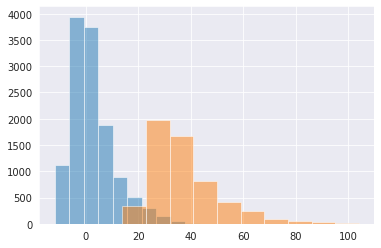

In [76]:
import matplotlib.pyplot as plt

print(scores_vim_in.min())
print(scores_vim_ood.min())
plt.hist(scores_vim_in, alpha=0.5)
plt.hist(scores_vim_ood, alpha=0.5)

12607
(12630,)


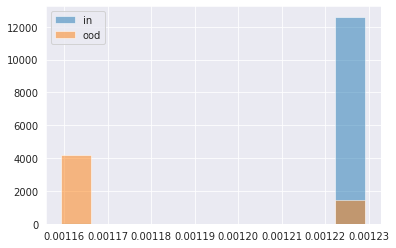

In [77]:
scores_naive_in = (
    -torch.load("outputs/2024-08-22/16-41-20/Textures-mlnp-in.pt").squeeze().numpy()
)
scores_naive_ood = (
    -torch.load("outputs/2024-08-22/16-41-20/Textures-mlnp-ood.pt").squeeze().numpy()
)

plt.hist(scores_naive_in, alpha=0.5, label="in")
plt.hist(scores_naive_ood, alpha=0.5, label="ood")
plt.legend()

print((scores_naive_in > 0.0012).sum())
print(scores_naive_in.shape)

In [78]:
from pytorch_ood.utils import OODMetrics
import numpy as np

In [79]:
m = OODMetrics()
m.update(torch.tensor(scores_vim_in), torch.ones(len(scores_vim_in)))
m.update(torch.tensor(scores_vim_ood), -torch.ones(len(scores_vim_ood)))
print(m.compute())

{'AUROC': 0.9620763063430786, 'AUPR-IN': 0.9272395968437195, 'AUPR-OUT': 0.9966116547584534, 'FPR95TPR': 0.07561361789703369}


In [81]:
from scipy.stats import genextreme

params = genextreme.fit(scores_vim_val)

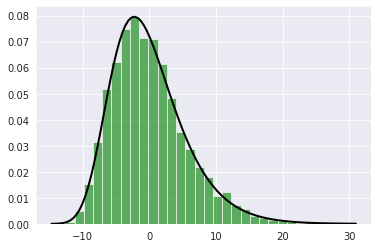

In [87]:
# Plot the histogram of the data
plt.hist(scores_vim_val, bins=30, density=True, alpha=0.6, color="g")

# Plot the PDF of the fitted distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = genextreme.pdf(x, *params)
plt.plot(x, p, "k", linewidth=2)

# title = "Fit results: mu = %.2f,  std = %.2f" % (mu, std)
# plt.title(title)

plt.show()

In [95]:
p_ood = genextreme.sf(scores_vim_ood, *params)
p_in = genextreme.sf(scores_vim_in, *params)

(array([5.366e+03, 1.730e+02, 6.400e+01, 1.800e+01, 7.000e+00, 2.000e+00,
        4.000e+00, 1.000e+00, 2.000e+00, 3.000e+00]),
 array([0.00000000e+00, 2.53996060e-06, 5.07992119e-06, 7.61988179e-06,
        1.01598424e-05, 1.26998030e-05, 1.52397636e-05, 1.77797242e-05,
        2.03196848e-05, 2.28596454e-05, 2.53996060e-05]),
 <BarContainer object of 10 artists>)

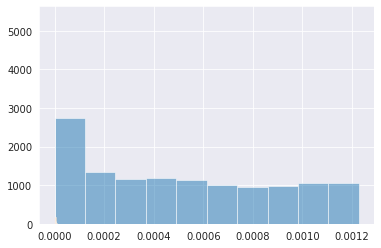

In [96]:
plt.hist(p_in * scores_naive_in, alpha=0.5)
plt.hist(p_ood * scores_naive_ood, alpha=0.5)

In [97]:
new_scores_in = p_in * scores_naive_in
new_scores_ood = p_ood * scores_naive_ood

# 0.99173188209
m = OODMetrics()
m.update(-torch.tensor(new_scores_in), torch.ones(len(new_scores_in)))
m.update(-torch.tensor(new_scores_ood), -torch.ones(len(new_scores_ood)))
print(m.compute())

{'AUROC': 0.9917318820953369, 'AUPR-IN': 0.9784691333770752, 'AUPR-OUT': 0.9966942071914673, 'FPR95TPR': 0.03444180637598038}


In [98]:
m = OODMetrics()
m.update(-torch.tensor(p_in), torch.ones(len(p_in)))
m.update(-torch.tensor(p_ood), -torch.ones(len(p_ood)))
print(m.compute())

{'AUROC': 0.9915232062339783, 'AUPR-IN': 0.9779255986213684, 'AUPR-OUT': 0.9966115951538086, 'FPR95TPR': 0.035471100360155106}


In [ ]:
# does this also work if i do not fit the distribution on the test data?
# does this also work with different methods?

In [69]:
import torch

scores_maha_in = torch.load(
    "outputs/2024-08-22/18-02-51/Textures-mahalanobis-in.pt", map_location="cpu"
).numpy()
scores_maha_val = torch.load(
    "outputs/2024-08-22/18-02-51/val-mahalanobis-in.pt", map_location="cpu"
).numpy()
scores_maha_ood = torch.load(
    "outputs/2024-08-22/18-02-51/Textures-mahalanobis-ood.pt", map_location="cpu"
).numpy()

(array([ 157., 1769., 2375.,  755.,  312.,  157.,   61.,   21.,   24.,
           9.]),
 array([0.04984146, 0.09485651, 0.13987155, 0.18488659, 0.22990164,
        0.27491668, 0.31993172, 0.36494675, 0.40996182, 0.45497686,
        0.49999189]),
 <BarContainer object of 10 artists>)

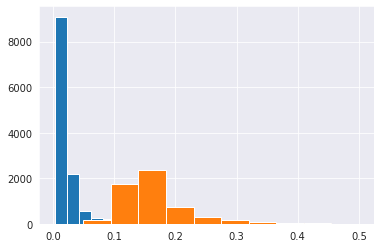

In [70]:
plt.hist(scores_maha_in)
plt.hist(scores_maha_ood)

KS Statistic: 0.009664234481820744
P-Value: 0.822939162520335


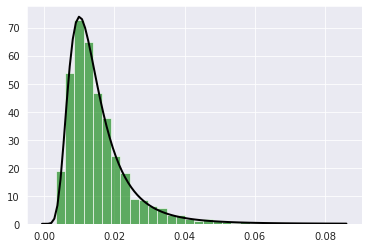

In [71]:
from scipy.stats import genextreme, skewnorm
from scipy.stats import kstest

#
# params = skewnorm.fit(scores_maha_val)
#
# # Perform the K-S test
# ks_stat, p_value = kstest(scores_maha_val, 'skewnorm', args=params)
#
# print(f"KS Statistic: {ks_stat}")
# print(f"P-Value: {p_value}")


params = genextreme.fit(scores_maha_val)

# Perform the K-S test
ks_stat, p_value = kstest(scores_maha_val, "genextreme", args=params)

print(f"KS Statistic: {ks_stat}")
print(f"P-Value: {p_value}")

# Plot the histogram of the data
plt.hist(scores_maha_val, bins=30, density=True, alpha=0.6, color="g")

# Plot the PDF of the fitted distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = genextreme.pdf(x, *params)
plt.plot(x, p, "k", linewidth=2)

# title = "Fit results: mu = %.2f,  std = %.2f" % (mu, std)
# plt.title(title)

plt.show()

In [72]:
p_ood = genextreme.sf(scores_maha_ood, *params)
p_in = genextreme.sf(scores_maha_in, *params)

new_scores_in = p_in * scores_naive_in
new_scores_ood = p_ood * scores_naive_ood

m = OODMetrics()
m.update(-torch.tensor(new_scores_in), torch.ones(len(new_scores_in)))
m.update(-torch.tensor(new_scores_ood), -torch.ones(len(new_scores_ood)))
print(m.compute())

{'AUROC': 0.9932083487510681, 'AUPR-IN': 0.9807600378990173, 'AUPR-OUT': 0.9973660707473755, 'FPR95TPR': 0.02327791042625904}


In [73]:
m = OODMetrics()
m.update(-torch.tensor(p_in), torch.ones(len(p_in)))
m.update(-torch.tensor(p_ood), -torch.ones(len(p_ood)))
print(m.compute())

{'AUROC': 0.9929179549217224, 'AUPR-IN': 0.9798016548156738, 'AUPR-OUT': 0.997260570526123, 'FPR95TPR': 0.02406967617571354}


In [8]:
import torch

model_color = torch.load("models/model-color-00000.pt", map_location="cpu")
model_shape = torch.load("models/model-shape-00000.pt", map_location="cpu")
model_label = torch.load("models/model-label-00000.pt", map_location="cpu")

In [17]:
from pytorch_ood.utils import ToRGB
from torchvision.transforms import Compose, ToTensor, Resize
from PIL import Image
from gtsrb import GTSRB


trans = Compose([ToRGB(), ToTensor(), Resize((32, 32), antialias=True)])


img = Image.open("/home/ki/stop-sign.png")

In [10]:
x = trans(img).unsqueeze(0)

In [12]:
with torch.no_grad():

    color = model_color(x)
    label = model_label(x)
    shape = model_shape(x)

In [20]:
c = GTSRB.color_to_name[color.argmax(1).item()]

l = GTSRB.class_to_name[label.argmax(1).item()]
s = GTSRB.shape_to_name[shape.argmax(1).item()]

In [21]:
c, l, s

('blue', 'go left', 'circle')

In [53]:
from transformers import CLIPProcessor, CLIPModel

device = "cuda"

torch_dtype = torch.float16


model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32", device_map=device, torch_dtype=torch_dtype
)

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [54]:
from tqdm.notebook import tqdm

text_color = [f"A photo of a {sign} sign" for sign in GTSRB.color_to_name.values()]
text_label = [f"A photo of a {sign} sign" for sign in GTSRB.class_to_name.values()]
text_shape = texts = [
    f"A photo of a sign in the shape of a {shape}"
    for shape in GTSRB.shape_to_name.values()
]

In [55]:
text_shape

['A photo of a sign in the shape of a triangle',
 'A photo of a sign in the shape of a circle',
 'A photo of a sign in the shape of a square',
 'A photo of a sign in the shape of a octagon',
 'A photo of a sign in the shape of a inverse triangle']

In [72]:
from pytorch_ood.dataset.img import Textures

dataset = GTSRB(root="../data/", train=True)

results_label = []
results_color = []
results_shape = []

with torch.no_grad():
    with torch.autocast(device):
        for i, (x, y) in enumerate(tqdm(dataset)):
            inputs = processor(
                text=text_color, images=x, return_tensors="pt", padding=True
            )
            inputs.to(device)
            outputs = model(**inputs)
            logits_per_image = (
                outputs.logits_per_image
            )  # this is the image-text similarity score
            results_color.append(logits_per_image)

            inputs = processor(
                text=text_label, images=x, return_tensors="pt", padding=True
            )
            inputs.to(device)
            outputs = model(**inputs)
            logits_per_image = (
                outputs.logits_per_image
            )  # this is the image-text similarity score
            results_label.append(logits_per_image)

            inputs = processor(
                text=text_shape, images=x, return_tensors="pt", padding=True
            )
            inputs.to(device)
            outputs = model(**inputs)
            logits_per_image = (
                outputs.logits_per_image
            )  # this is the image-text similarity score
            results_shape.append(logits_per_image)

  0%|          | 0/39209 [00:00<?, ?it/s]

In [73]:
dataset = GTSRB(root="../data/", train=False)

test_results_label = []
test_results_color = []
test_results_shape = []

with torch.no_grad():
    with torch.autocast(device):
        for i, (x, y) in enumerate(tqdm(dataset)):
            inputs = processor(
                text=text_color, images=x, return_tensors="pt", padding=True
            )
            inputs.to(device)
            outputs = model(**inputs)
            logits_per_image = (
                outputs.logits_per_image
            )  # this is the image-text similarity score
            test_results_color.append(logits_per_image)

            inputs = processor(
                text=text_label, images=x, return_tensors="pt", padding=True
            )
            inputs.to(device)
            outputs = model(**inputs)
            logits_per_image = (
                outputs.logits_per_image
            )  # this is the image-text similarity score
            test_results_label.append(logits_per_image)

            inputs = processor(
                text=text_shape, images=x, return_tensors="pt", padding=True
            )
            inputs.to(device)
            outputs = model(**inputs)
            logits_per_image = (
                outputs.logits_per_image
            )  # this is the image-text similarity score
            test_results_shape.append(logits_per_image)

  0%|          | 0/12630 [00:00<?, ?it/s]

In [74]:
dataset = Textures(root="../data/", download=True)

textures_results_label = []
textures_results_color = []
textures_results_shape = []

with torch.no_grad():
    with torch.autocast(device):
        for i, (x, y) in enumerate(tqdm(dataset)):
            inputs = processor(
                text=text_color, images=x, return_tensors="pt", padding=True
            )
            inputs.to(device)
            outputs = model(**inputs)
            logits_per_image = (
                outputs.logits_per_image
            )  # this is the image-text similarity score
            textures_results_color.append(logits_per_image)

            inputs = processor(
                text=text_label, images=x, return_tensors="pt", padding=True
            )
            inputs.to(device)
            outputs = model(**inputs)
            logits_per_image = (
                outputs.logits_per_image
            )  # this is the image-text similarity score
            textures_results_label.append(logits_per_image)

            inputs = processor(
                text=text_shape, images=x, return_tensors="pt", padding=True
            )
            inputs.to(device)
            outputs = model(**inputs)
            logits_per_image = (
                outputs.logits_per_image
            )  # this is the image-text similarity score
            textures_results_shape.append(logits_per_image)

  0%|          | 0/5640 [00:00<?, ?it/s]

In [75]:
results_label_tensor = torch.cat(results_label).cpu()
results_color_tensor = torch.cat(results_color).cpu()
results_shape_tensor = torch.cat(results_shape).cpu()

In [82]:
results_label_tensor.softmax(1).max(1).indices

tensor([36, 36, 36,  ..., 37,  4, 29])

In [108]:
dataset = GTSRB(root="../data/", train=True)
labels = [i[1][0] for i in dataset]
colors = [i[1][1] for i in dataset]
shapes = [i[1][2] for i in dataset]

In [92]:
(torch.tensor(labels) == results_label_tensor.softmax(1).max(1).indices).sum() / len(
    labels
)

tensor(0.2965)

In [4]:
import pandas as pd

df = pd.read_pickle("outputs/2024-10-24/13-41-01/results-agg.pkl")

In [5]:
df

AUROC              AUPR-IN             AUPR-OUT  \
                        mean                 mean                 mean   
                        mean       sem       mean       sem       mean   
Method                                                                   
DICE               99.291193  0.157785  99.515948  0.095749  98.658655   
EBO                99.285733  0.157789  99.512775  0.095622  98.646240   
Ensemble           99.126565  0.124018  99.457575  0.055674  98.413889   
Entropy            98.957797  0.140726  99.360487  0.060163  98.128206   
Logic              60.152183  1.550091  74.934449  0.839662  68.047898   
LogicOOD           64.351062  0.979291  79.970810  0.683565  69.381145   
MLN-DICE           99.165092  0.147995  99.549186  0.080421  98.684043   
MLN-EBO            99.205521  0.150061  99.555945  0.081212  98.735094   
MLN-MSP            98.674278  0.121451  99.245940  0.039961  97.408226   
MLN-Mahalanobis    99.132293  0.029464  99.528290  0.031953  98.170035   
MLN-OOD            87.474886  0.848753  80.110860  1.349138  88.135432   
MLN-OOD-Untrained  99.126573  0.124024  79.237320  1.331886  98.413893   
MLN-Prob           56.818486  1.963291  64.344141  3.093979  58.132272   
MLN-ViM            99.493374  0.032590  99.691989  0.014416  99.131800   
MSP                98.720769  0.133949  99.251517  0.050292  97.551125   
Mahalanobis        99.200819  0.029607  99.566230  0.025649  98.314394   
ViM                95.686142  0.000909  99.701282  0.012721  94.447664   

                               FPR95TPR            
                                   mean            
                        sem        mean       sem  
Method                                             
DICE               0.384486    2.299287  0.447215  
EBO                0.384861    2.335709  0.445751  
Ensemble           0.368242    3.336500  0.243055  
Entropy            0.455768    3.718131  0.321545  
Logic              3.169336  100.000000  0.000000  
LogicOOD           3.009456   59.708630  0.284104  
MLN-DICE           0.368601    2.307205  0.450616  
MLN-EBO            0.364510    2.332542  0.445072  
MLN-MSP            0.516801    3.920823  0.316690  
MLN-Mahalanobis    0.249601    2.549485  0.082928  
MLN-OOD            0.823649   68.292953  1.020910  
MLN-OOD-Untrained  0.368255    3.336500  0.243055  
MLN-Prob           1.705983   88.820267  0.000000  
MLN-ViM            0.174464    2.296120  0.152443  
MSP                0.527944    3.857482  0.313977  
Mahalanobis        0.250403    2.354711  0.119543  
ViM                0.638553    8.622327  0.000000

In [10]:
df.reset_index()["AUROC", "mean", "mean"]

0     99.291193
1     99.285733
2     99.126565
3     98.957797
4     60.152183
5     64.351062
6     99.165092
7     99.205521
8     98.674278
9     99.132293
10    87.474886
11    99.126573
12    56.818486
13    99.493374
14    98.720769
15    99.200819
16    95.686142
Name: (AUROC, mean, mean), dtype: float64

In [8]:
# % md

In [13]:
import pandas as pd
from omegaconf import OmegaConf

x = []
y = []

for i in range(43):
    try:
        df = pd.read_pickle(f"multirun/grakadu/2025-01-13/17-42-39/{i}/results-agg.pkl")

        auroc = df.loc["MLN-Ensemble"]["AUROC"]["mean"]["mean"]
        cfg = OmegaConf.load(f"multirun/2024-11-05/18-06-35/{i}/.hydra/config.yaml")
        y.append(auroc)
        x.append(cfg.ablation_n_rules)
    except:
        print(i)
        pass

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42


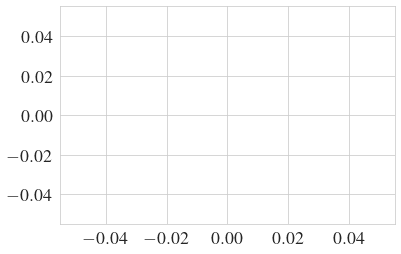

In [14]:
import matplotlib.pyplot as plt

plt.plot(x[1:], y[1:])

In [15]:
cfg

NameError: name 'cfg' is not defined

In [14]:
import seaborn as sb
import pandas as pd

dfs = []
# sftp://grakadu-int/data/slow/kirchhei/mln-ood/gtsrb/multirun/2025-01-14

for i in range(1, 44):
    try:
        df = pd.read_pickle(f"multirun/grakadu/2025-01-14/11-34-12/{i}/results.pkl")
        tmp = df[df.Method.isin(["MLN+Ensemble", "MLN", "Ensemble"])][
            ["AUROC", "Seed", "Method", "Dataset"]
        ]
        tmp["Number of Rules"] = i
        dfs.append(tmp)
    except Exception as e:
        print(i, e)
        pass

In [15]:
df = pd.concat(dfs)

In [16]:
df.to_csv("/home/ki/gtsrb-ablation-no-rules.csv")

In [1]:
import pandas as pd

df = pd.read_csv("/home/ki/projects/work/phd-thesis-img/chapter04/mln/gtsrb/ablation-no-rules.csv")

<ipython-input-3-839b5c26df9e>:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sb.lineplot(


<Axes: xlabel='Number of Rules', ylabel='AUROC'>

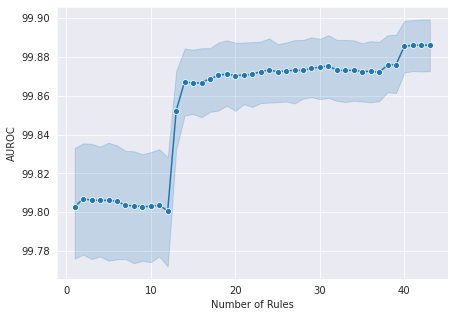

In [3]:
import matplotlib.pyplot as plt
import seaborn as sb


plt.figure(figsize=(7, 5))

sb.lineplot(
    df[df.Method == "MLN+Ensemble"], x="Number of Rules", y="AUROC", ci=95, marker="o"
)

In [4]:
df.Method.unique()

array(['Ensemble', 'MLN', 'MLN+Ensemble'], dtype=object)

<ipython-input-5-57be1b6ff551>:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sb.lineplot(df[df.Method == "MLN"], x="Number of Rules", y="AUROC", ci=95, marker="o")


<Axes: xlabel='Number of Rules', ylabel='AUROC'>

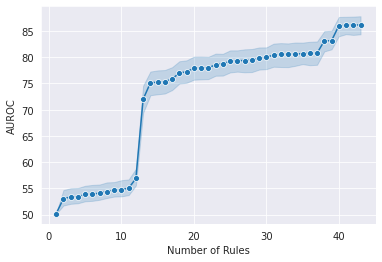

In [5]:
sb.lineplot(df[df.Method == "MLN"], x="Number of Rules", y="AUROC", ci=95, marker="o")

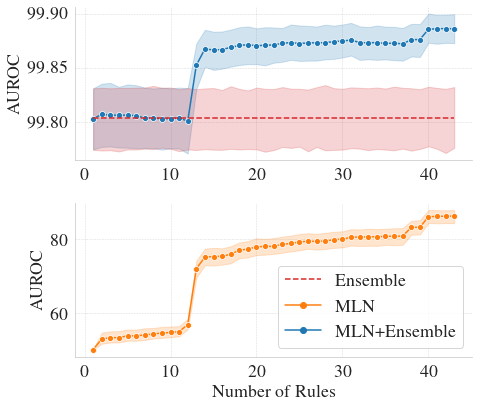

In [7]:
import matplotlib.pyplot as plt
import seaborn as sb
import matplotlib.lines as mlines

sb.set_style("whitegrid")
gridline_style = {"color": "gray", "linestyle": "--", "linewidth": 0.5, "alpha": 0.3}

# Enable LaTeX rendering in matplotlib
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
# Increase font size for better readability
plt.rcParams.update({"font.size": 18})

# Set colors for consistency
colors = ["tab:blue", "tab:orange", "tab:red"]

# Create a figure with two vertical subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6))

# First subplot
sb.lineplot(
    data=df[df.Method == "MLN+Ensemble"],
    x="Number of Rules", y="AUROC",
    errorbar=("ci", 95), marker="o",
    color=colors[0], ax=ax1,
)
sb.lineplot(
    data=df[df.Method == "Ensemble"],
    x="Number of Rules", y="AUROC",
    errorbar=("ci", 95), linestyle="--",
    color=colors[2], ax=ax1,
)
ax1.set_xlabel("")
ax1.grid(**gridline_style)
# remove top and right spines
sb.despine(ax=ax1, top=True, right=True)

# Second subplot
sb.lineplot(
    data=df[df.Method == "MLN"],
    x="Number of Rules", y="AUROC",
    errorbar=("ci", 95), marker="o",
    color=colors[1], ax=ax2,
)
# combined legend
mln_ensemble = mlines.Line2D([], [], color=colors[0], marker="o", linestyle="-", label="MLN+Ensemble")
ensemble    = mlines.Line2D([], [], color=colors[2], linestyle="--", label="Ensemble")
mln         = mlines.Line2D([], [], color=colors[1], marker="o", linestyle="-", label="MLN")
ax2.legend(handles=[ensemble, mln, mln_ensemble], loc="lower right")
ax2.grid(**gridline_style)
# remove top and right spines
sb.despine(ax=ax2, top=True, right=True)

plt.tight_layout()
plt.savefig("/home/ki/rule-plot.pdf", bbox_inches="tight")
plt.show()


In [129]:
ax1.get_legend_handles_labels()

([<matplotlib.lines.Line2D at 0x760860250640>,
 ['MLN+Ensemble', 'Ensemble'])

/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-p

<Axes: xlabel='Number of Rules', ylabel='AUROC'>

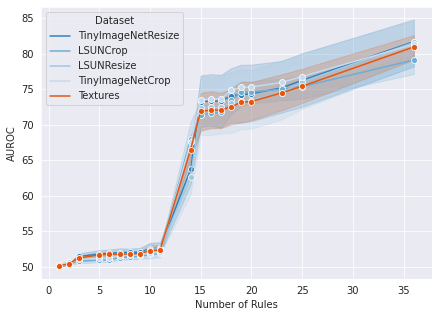

In [92]:
plt.figure(figsize=(7, 5))

sb.lineplot(
    df[df.Method == "MLN-Prob"],
    x="Number of Rules",
    y="AUROC",
    hue="Dataset",
    errorbar=("ci", 95),
    marker="o",
    palette="tab20c",
)

/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ki/.local/share/anaconda3/envs/pytorch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning

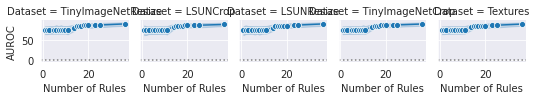

In [88]:
import numpy as np

# Initialize a grid of plots with an Axes for each walk
grid = sb.FacetGrid(df, col="Dataset", palette="tab20c", height=1.5)

# Draw a line plot to show the trajectory of each random walk
grid.map(sb.lineplot, "Number of Rules", "AUROC", marker="o")


# Draw a horizontal line to show the starting point
grid.refline(y=0, linestyle=":")

# Adjust the tick positions and labels
# grid.set(xticks=np.arange(1, 42),
#          xlim=(-.5, 4.5), ylim=(-3.5, 3.5))

# Adjust the arrangement of the plots
grid.fig.tight_layout(w_pad=1)

In [82]:
df

,AUROC,Seed,Method,Number of Rules
0,50.295001,0,MLN-Prob,1
0,99.504447,0,MLN-Ensemble,1
0,50.305003,0,MLN-Prob,1
0,99.324763,0,MLN-Ensemble,1
0,50.145000,0,MLN-Prob,1
...,...,...,...,...
0,99.530864,9,MLN-Ensemble,36
0,76.478946,9,MLN-Prob,36
0,99.728161,9,MLN-Ensemble,36
0,77.222776,9,MLN-Prob,36


In [22]:
import torch

path = "/run/media/ki/data/mln-ood/gtsrb/predictions/vit/data-test-00000.pt"

data = torch.load(path)

In [23]:
data["labels"].shape

torch.Size([12630, 3])

In [24]:
list(data.keys())

['shape-logits',
 'shape-features',
 'color-logits',
 'color-features',
 'label-logits',
 'label-features',
 'labels',
 'oe-logits',
 'oe-features']

In [25]:
shapes = data["shape-logits"].argmax(dim=1)

shapes.unique()

tensor([1])

In [26]:
data["labels"].max(dim=0)

torch.return_types.max(
values=tensor([42,  3,  4]),
indices=tensor([315,  95,  26]))

In [27]:
data["shape-logits"]

tensor([[ 0.8033,  1.7624, -0.5761, -1.5499, -0.4310],
        [ 0.7735,  1.7100, -0.5689, -1.5048, -0.3946],
        [ 0.8868,  1.9204, -0.5954, -1.6800, -0.5451],
        ...,
        [ 1.0356,  2.2214, -0.6355, -1.9275, -0.7500],
        [ 1.0296,  2.2091, -0.6346, -1.9188, -0.7407],
        [ 1.0592,  2.2725, -0.6440, -1.9736, -0.7814]])

In [28]:
labels = data["label-logits"].argmax(dim=1)
labels.unique()

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42])

In [29]:
colors = data["color-logits"].argmax(dim=1)
colors.unique()

tensor([0, 1])

In [30]:
data["color-logits"]

tensor([[ 2.0006, -0.6811,  0.0145, -1.3777],
        [ 2.7526, -1.6429,  0.1998, -1.2663],
        [-0.8190,  4.2572, -0.4821, -2.6363],
        ...,
        [ 1.7103, -1.0840, -0.4156, -0.2315],
        [ 2.6704, -2.5235, -0.2461,  0.0710],
        [ 3.1027, -3.2709, -0.2587,  0.4469]])

In [32]:
import pandas as pd

In [60]:
# convnext
df = pd.read_pickle("outputs/2024-11-18/17-18-59/results-agg.pkl")

d = df.loc["EBO"]["AUROC"]["mean"]["mean"]
c = df.loc["MLN-Prob"]["AUROC"]["mean"]["mean"]
a = df.loc["Ensemble"]["AUROC"]["mean"]["mean"]
b = df.loc["MLN-Ensemble"]["AUROC"]["mean"]["mean"]
print(f"EBO: \t\t\t {d:.2f} + {df.loc['EBO']['FPR95TPR']['mean']['sem']:.1f}")
print(f"Ensemble:\t\t {a:.1f} + {df.loc['Ensemble']['AUROC']['mean']['sem']:.2f}")
print(f"MLN: \t\t\t {c:.1f} + {df.loc['MLN-Prob']['AUROC']['mean']['sem']:.2f}")
print(f"MLN+Ensemble:\t {b:.2f} + {df.loc['MLN-Ensemble']['AUROC']['mean']['sem']:.2f}")

print("-----")
# print(f"{b-a:.1f}")
d = df.loc["EBO"]["FPR95TPR"]["mean"]["mean"]
c = df.loc["MLN-Prob"]["FPR95TPR"]["mean"]["mean"]
a = df.loc["Ensemble"]["FPR95TPR"]["mean"]["mean"]
b = df.loc["MLN-Ensemble"]["FPR95TPR"]["mean"]["mean"]
print(f"EBO: \t\t\t {d:.1f} + {df.loc['EBO']['FPR95TPR']['mean']['sem']:.1f}")
print(f"Ensemble:\t\t {a:.1f} + {df.loc['Ensemble']['FPR95TPR']['mean']['sem']:.1f}")
print(f"MLN: \t\t\t {c:.1f} + {df.loc['MLN-Prob']['FPR95TPR']['mean']['sem']:.1f}")
print(
    f"MLN+Ensemble:\t {b:.1f} + {df.loc['MLN-Ensemble']['FPR95TPR']['mean']['sem']:.1f}"
)

EBO: 			 98.12 + 1.1
Ensemble:		 98.9 + 0.10
MLN: 			 86.0 + 0.55
MLN+Ensemble:	 99.25 + 0.07
-----
EBO: 			 9.2 + 1.1
Ensemble:		 6.6 + 0.6
MLN: 			 100.0 + 0.0
MLN+Ensemble:	 3.1 + 0.4


In [59]:
# resnet18
df = pd.read_pickle("outputs/2024-11-12/16-54-45/results-agg.pkl")

d = df.loc["EBO"]["AUROC"]["mean"]["mean"]
c = df.loc["MLN-Prob"]["AUROC"]["mean"]["mean"]
a = df.loc["Ensemble"]["AUROC"]["mean"]["mean"]
b = df.loc["MLN-Ensemble"]["AUROC"]["mean"]["mean"]
print(f"EBO: \t\t\t {d:.2f} + {df.loc['EBO']['FPR95TPR']['mean']['sem']:.1f}")
print(f"Ensemble:\t\t {a:.1f} + {df.loc['Ensemble']['AUROC']['mean']['sem']:.2f}")
print(f"MLN: \t\t\t {c:.1f} + {df.loc['MLN-Prob']['AUROC']['mean']['sem']:.2f}")
print(f"MLN+Ensemble:\t {b:.2f} + {df.loc['MLN-Ensemble']['AUROC']['mean']['sem']:.2f}")

print("-----")
# print(f"{b-a:.1f}")
d = df.loc["EBO"]["FPR95TPR"]["mean"]["mean"]
c = df.loc["MLN-Prob"]["FPR95TPR"]["mean"]["mean"]
a = df.loc["Ensemble"]["FPR95TPR"]["mean"]["mean"]
b = df.loc["MLN-Ensemble"]["FPR95TPR"]["mean"]["mean"]
print(f"EBO: \t\t\t {d:.1f} + {df.loc['EBO']['FPR95TPR']['mean']['sem']:.1f}")
print(f"Ensemble:\t\t {a:.1f} + {df.loc['Ensemble']['FPR95TPR']['mean']['sem']:.1f}")
print(f"MLN: \t\t\t {c:.1f} + {df.loc['MLN-Prob']['FPR95TPR']['mean']['sem']:.1f}")
print(
    f"MLN+Ensemble:\t {b:.1f} + {df.loc['MLN-Ensemble']['FPR95TPR']['mean']['sem']:.1f}"
)

# print(f"{b-a:.1f}")

EBO: 			 98.35 + 0.6
Ensemble:		 98.2 + 0.04
MLN: 			 81.4 + 0.33
MLN+Ensemble:	 98.96 + 0.05
-----
EBO: 			 5.9 + 0.6
Ensemble:		 5.9 + 0.2
MLN: 			 96.7 + 2.3
MLN+Ensemble:	 4.4 + 0.3


In [37]:
print(list(df.reset_index()["Method"].unique()))

['DICE', 'EBO', 'Ensemble', 'Entropy', 'Logic', 'Logic+Ensemble', 'Logic-Ensemble', 'MLN+DICE', 'MLN+EBO', 'MLN+Ensemble', 'MLN+Mahalanobis', 'MLN+ViM', 'MLN-DICE', 'MLN-EBO', 'MLN-Ensemble', 'MLN-Ensemble-Untrained', 'MLN-MSP', 'MLN-Mahalanobis', 'MLN-Prob', 'MLN-ViM', 'MSP', 'Mahalanobis', 'ViM']


In [58]:
# wrn40
df = pd.read_pickle("outputs/2024-11-19/13-19-40/results-agg.pkl")

d = df.loc["EBO"]["AUROC"]["mean"]["mean"]
c = df.loc["MLN-Prob"]["AUROC"]["mean"]["mean"]
a = df.loc["Ensemble"]["AUROC"]["mean"]["mean"]
b = df.loc["MLN-Ensemble"]["AUROC"]["mean"]["mean"]
print(f"EBO: \t\t\t {d:.2f} + {df.loc['EBO']['FPR95TPR']['mean']['sem']:.1f}")
print(f"Ensemble:\t\t {a:.1f} + {df.loc['Ensemble']['AUROC']['mean']['sem']:.2f}")
print(f"MLN: \t\t\t {c:.1f} + {df.loc['MLN-Prob']['AUROC']['mean']['sem']:.2f}")
print(f"MLN+Ensemble:\t {b:.2f} + {df.loc['MLN-Ensemble']['AUROC']['mean']['sem']:.2f}")

print("-----")
# print(f"{b-a:.1f}")
d = df.loc["EBO"]["FPR95TPR"]["mean"]["mean"]
c = df.loc["MLN-Prob"]["FPR95TPR"]["mean"]["mean"]
a = df.loc["Ensemble"]["FPR95TPR"]["mean"]["mean"]
b = df.loc["MLN-Ensemble"]["FPR95TPR"]["mean"]["mean"]
print(f"EBO: \t\t\t {d:.1f} + {df.loc['EBO']['FPR95TPR']['mean']['sem']:.1f}")
print(f"Ensemble:\t\t {a:.1f} + {df.loc['Ensemble']['FPR95TPR']['mean']['sem']:.1f}")
print(f"MLN: \t\t\t {c:.1f} + {df.loc['MLN-Prob']['FPR95TPR']['mean']['sem']:.1f}")
print(
    f"MLN+Ensemble:\t {b:.1f} + {df.loc['MLN-Ensemble']['FPR95TPR']['mean']['sem']:.1f}"
)

EBO: 			 99.12 + 0.3
Ensemble:		 99.4 + 0.05
MLN: 			 88.6 + 1.35
MLN+Ensemble:	 99.71 + 0.03
-----
EBO: 			 2.8 + 0.3
Ensemble:		 2.2 + 0.1
MLN: 			 92.2 + 5.2
MLN+Ensemble:	 1.2 + 0.2


In [57]:
import pandas as pd

# vit
df = pd.read_pickle("outputs/2024-11-20/15-07-28/results-agg.pkl")
d = df.loc["EBO"]["AUROC"]["mean"]["mean"]
c = df.loc["MLN-Prob"]["AUROC"]["mean"]["mean"]
a = df.loc["Ensemble"]["AUROC"]["mean"]["mean"]
b = df.loc["MLN-Ensemble"]["AUROC"]["mean"]["mean"]
print(f"EBO: \t\t\t {d:.2f} + {df.loc['EBO']['FPR95TPR']['mean']['sem']:.1f}")
print(f"Ensemble:\t\t {a:.1f} + {df.loc['Ensemble']['AUROC']['mean']['sem']:.2f}")
print(f"MLN: \t\t\t {c:.1f} + {df.loc['MLN-Prob']['AUROC']['mean']['sem']:.2f}")
print(f"MLN+Ensemble:\t {b:.2f} + {df.loc['MLN-Ensemble']['AUROC']['mean']['sem']:.2f}")

print("-----")
# print(f"{b-a:.1f}")
d = df.loc["EBO"]["FPR95TPR"]["mean"]["mean"]
c = df.loc["MLN-Prob"]["FPR95TPR"]["mean"]["mean"]
a = df.loc["Ensemble"]["FPR95TPR"]["mean"]["mean"]
b = df.loc["MLN-Ensemble"]["FPR95TPR"]["mean"]["mean"]
print(f"EBO: \t\t\t {d:.1f} + {df.loc['EBO']['FPR95TPR']['mean']['sem']:.1f}")
print(f"Ensemble:\t\t {a:.1f} + {df.loc['Ensemble']['FPR95TPR']['mean']['sem']:.1f}")
print(f"MLN: \t\t\t {c:.1f} + {df.loc['MLN-Prob']['FPR95TPR']['mean']['sem']:.1f}")
print(
    f"MLN+Ensemble:\t {b:.1f} + {df.loc['MLN-Ensemble']['FPR95TPR']['mean']['sem']:.1f}"
)

EBO: 			 99.94 + 0.1
Ensemble:		 99.9 + 0.02
MLN: 			 86.1 + 1.20
MLN+Ensemble:	 99.88 + 0.01
-----
EBO: 			 0.2 + 0.1
Ensemble:		 0.1 + 0.0
MLN: 			 87.5 + 8.2
MLN+Ensemble:	 0.3 + 0.0


In [14]:
from scipy.stats import ttest_ind, ttest_rel

df = pd.read_pickle(
    "/home/ki/projects/work/mln-ood/gtsrb/outputs/2025-01-10/12-24-13/results.pkl"
)
a = df[df["Method"] == "MLN+Ensemble"][["AUROC", "Seed"]].groupby(by="Seed").mean()
b = df[df["Method"] == "Ensemble"][["AUROC", "Seed"]].groupby(by="Seed").mean()

ttest_rel(a, b)

TtestResult(statistic=array([3.46362]), pvalue=array([0.00712004]), df=array([9]))

In [15]:
df

,AUROC,AUTC,AUPR-IN,AUPR-OUT,FPR95TPR,Dataset,Method,Seed
0,99.545312,26.700163,99.698532,99.291050,2.153603,LSUNCrop,ViM,0
0,98.695272,30.088210,98.502392,98.451060,2.628662,LSUNCrop,DICE,0
0,99.224889,29.567966,99.542183,98.487002,2.319873,LSUNCrop,Mahalanobis,0
0,98.923254,33.678526,99.094296,98.342144,2.945368,LSUNCrop,MSP,0
0,98.999500,33.772573,99.113595,98.567975,2.882027,LSUNCrop,Entropy,0
...,...,...,...,...,...,...,...,...
0,99.999839,28.668992,99.999988,99.997902,0.000000,UniformNoise,MLN+ViM+,9
0,99.917185,2.114566,99.993902,96.433520,0.095012,UniformNoise,MLN+EBO+,9
0,99.641752,27.441129,99.973011,91.458941,0.752177,UniformNoise,MLN+Dice+,9
0,99.987072,28.608308,99.999028,99.703825,0.023753,UniformNoise,MLN+Mahalanobis+,9


In [23]:
import pandas as pd
import re


# ReAct not there
desired_order = [
    "MSP",
    "EBO",
    "Entropy",
    "Ensemble",
    "Mahalanobis",
    "SHE",
    "ViM",
    "DICE",
    "ReAct",
    "Logic",
    "Logic+Ensemble",
    "MLN",
    "MLN+Ensemble",
    "MLN+Mahalanobis",
    "Logic+Ensemble+",
    "MLN+Ensemble+",
    "MLN+Mahalanobis+",
]

path = "outputs/2025-01-24/18-17-28/results-agg.pkl"

df = pd.read_pickle(path)


for metric in ["AUROC", "AUPR-IN", "AUPR-OUT", "FPR95TPR"]:
    df[(metric, "mean", "sem")] = df[(metric, "mean", "sem")].apply(
        lambda x: "$\pm {:.2f}$".format(x)
    )

reordered_df = df.reindex(desired_order)

s = reordered_df.to_latex(float_format="{:.2f}".format)
# s = s.replace("Logic", "Naïve Logic").replace("MLN-OOD-Untrained", "MLN-OOD (Untrained)")

s = re.sub(r"&", r"& & &", s, count=1)

print(s)

\begin{tabular}{lrlrlrlrl}
\toprule
 & & & \multicolumn{2}{r}{AUROC} & \multicolumn{2}{r}{AUPR-IN} & \multicolumn{2}{r}{AUPR-OUT} & \multicolumn{2}{r}{FPR95TPR} \\
 & \multicolumn{2}{r}{mean} & \multicolumn{2}{r}{mean} & \multicolumn{2}{r}{mean} & \multicolumn{2}{r}{mean} \\
 & mean & sem & mean & sem & mean & sem & mean & sem \\
Method &  &  &  &  &  &  &  &  \\
\midrule
MSP & 98.96 & $\pm 0.25$ & 99.04 & $\pm 0.30$ & 96.62 & $\pm 1.19$ & 3.04 & $\pm 0.81$ \\
EBO & 99.05 & $\pm 0.34$ & 98.85 & $\pm 0.39$ & 98.28 & $\pm 0.46$ & 3.58 & $\pm 1.80$ \\
Entropy & 99.11 & $\pm 0.25$ & 99.10 & $\pm 0.30$ & 97.67 & $\pm 0.75$ & 2.91 & $\pm 0.87$ \\
Ensemble & 99.80 & $\pm 0.03$ & 99.84 & $\pm 0.05$ & 99.35 & $\pm 0.22$ & 0.86 & $\pm 0.15$ \\
Mahalanobis & 99.23 & $\pm 0.08$ & 99.55 & $\pm 0.13$ & 94.67 & $\pm 2.31$ & 1.85 & $\pm 0.27$ \\
SHE & 84.13 & $\pm 2.18$ & 83.23 & $\pm 4.39$ & 84.69 & $\pm 1.63$ & 61.00 & $\pm 9.20$ \\
ViM & 99.47 & $\pm 0.08$ & 99.63 & $\pm 0.13$ & 97.30 & $\pm 1.18$ 

In [1]:
# compute gain on different base detectors
import pandas as pd

path = (
    "/home/ki/projects/work/mln-ood/gtsrb/outputs/2025-01-24/18-17-28/results-agg.pkl"
)

df = pd.read_pickle(path)

markup = "\color{green}{\scriptsize $\Delta$"
markup_end = "}"


for detector in [
    "MSP",
    "Ensemble",
    "DICE",
    "SHE",
    "ReAct",
    "Mahalanobis",
    "ViM",
    "EBO",
]:
    perf1 = df.loc[detector]["AUROC"]["mean"]["mean"]
    perf2 = df.loc[f"MLN+{detector}"]["AUROC"]["mean"]["mean"]
    perf3 = df.loc[f"MLN+{detector}+"]["AUROC"]["mean"]["mean"]

    print(
        f"{detector:<15} & {perf1:>5.2f} & {perf2:>5.2f}  {markup} {perf2 - perf1:>5.2f} {markup_end} & {perf3:>5.2f}   {markup} {perf3 - perf2:>5.2f} {markup_end} \\\\ "
    )

MSP             & 98.96 & 99.60  \color{green}{\scriptsize $\Delta$  0.64 } & 99.90   \color{green}{\scriptsize $\Delta$  0.30 } \\ 
Ensemble        & 99.80 & 99.88  \color{green}{\scriptsize $\Delta$  0.08 } & 99.96   \color{green}{\scriptsize $\Delta$  0.08 } \\ 
DICE            & 99.04 & 99.50  \color{green}{\scriptsize $\Delta$  0.46 } & 99.77   \color{green}{\scriptsize $\Delta$  0.27 } \\ 
SHE             & 84.13 & 95.04  \color{green}{\scriptsize $\Delta$ 10.91 } & 99.83   \color{green}{\scriptsize $\Delta$  4.79 } \\ 
ReAct           & 96.85 & 99.09  \color{green}{\scriptsize $\Delta$  2.24 } & 99.92   \color{green}{\scriptsize $\Delta$  0.82 } \\ 
Mahalanobis     & 99.23 & 99.72  \color{green}{\scriptsize $\Delta$  0.49 } & 99.96   \color{green}{\scriptsize $\Delta$  0.23 } \\ 
ViM             & 99.47 & 99.80  \color{green}{\scriptsize $\Delta$  0.33 } & 99.96   \color{green}{\scriptsize $\Delta$  0.16 } \\ 
EBO             & 99.05 & 99.50  \color{green}{\scriptsize $\Delta$  

In [2]:
# compute difference between models using a shared backbone

df_shared = pd.read_pickle(
    "/home/ki/projects/work/mln-ood/gtsrb/outputs/2025-01-28/15-29-13/results-agg.pkl"
)

markup = "\color{red}{\scriptsize $\Delta$"
markup_end = "}"

for key in ["Ensemble", "Logic", "Logic+Ensemble", "MLN", "MLN+Ensemble"]:
    org_perf = df.loc[key]["AUROC"]["mean"]["mean"]
    shared_perf = df_shared.loc[key]["AUROC"]["mean"]["mean"]

    org_perf_fpr = df.loc[key]["FPR95TPR"]["mean"]["mean"]
    shared_perf_fpr = df_shared.loc[key]["FPR95TPR"]["mean"]["mean"]

    print(
        f"{key:<20} & \t {shared_perf:>10.2f} &\t  {markup} {shared_perf - org_perf:>10.2f} {markup_end} & {shared_perf_fpr:>10.2f} &  {markup} {shared_perf_fpr - org_perf_fpr:>10.2f} {markup_end}  \\\\ "
    )

Ensemble             & 	      99.14 &	  \color{red}{\scriptsize $\Delta$      -0.67 } &       3.28 &  \color{red}{\scriptsize $\Delta$       2.42 }  \\ 
Logic                & 	      47.69 &	  \color{red}{\scriptsize $\Delta$     -38.47 } &     100.00 &  \color{red}{\scriptsize $\Delta$       6.24 }  \\ 
Logic+Ensemble       & 	      56.96 &	  \color{red}{\scriptsize $\Delta$     -42.90 } &      60.01 &  \color{red}{\scriptsize $\Delta$      59.53 }  \\ 
MLN                  & 	      53.61 &	  \color{red}{\scriptsize $\Delta$     -32.55 } &     100.00 &  \color{red}{\scriptsize $\Delta$       6.24 }  \\ 
MLN+Ensemble         & 	      98.88 &	  \color{red}{\scriptsize $\Delta$      -1.01 } &       3.67 &  \color{red}{\scriptsize $\Delta$       3.19 }  \\ 


In [32]:
df_shared

AUROC              AUPR-IN             AUPR-OUT  \
                      mean                 mean                 mean   
                      mean       sem       mean       sem       mean   
Method                                                                 
DICE             99.457164  0.089935  99.623101  0.106742  97.819517   
EBO              99.453404  0.090537  99.620327  0.107443  97.811735   
Ensemble         99.135613  0.072863  99.448772  0.146349  96.194342   
Entropy          98.895281  0.107941  99.296131  0.182302  95.356523   
Logic            47.691349  2.818757  69.662972  5.653091  53.851637   
Logic+Ensemble   56.958445  1.675324  77.174544  4.324106  56.187479   
MLN              60.226328  0.726738  69.442434  6.729940  56.078561   
MLN+DICE         99.418875  0.086554  99.630418  0.102202  97.899172   
MLN+EBO          85.971976  1.448754  85.917675  3.767507  79.999576   
MLN+Ensemble     99.028757  0.069776  99.404498  0.153916  95.207790   
MLN+MSP          71.875306  0.830115  76.152012  5.695167  61.761193   
MLN+Mahalanobis  98.542736  0.058718  99.238007  0.193160  90.982024   
MLN+ViM          98.828131  0.081455  99.296363  0.223173  93.583423   
MLN-Untrained    77.210940  2.348133  85.937225  3.296926  72.190275   
MSP              98.697042  0.105523  99.208715  0.199579  94.219634   
Mahalanobis      98.777323  0.055854  99.372945  0.160769  91.172616   
ViM              98.884356  0.086350  99.330488  0.216184  93.955682   

                             FPR95TPR            
                                 mean            
                      sem        mean       sem  
Method                                           
DICE             0.794107    1.805556  0.299679  
EBO              0.794295    1.825020  0.299499  
Ensemble         1.687073    3.278734  0.220855  
Entropy          1.912124    3.872229  0.359216  
Logic            7.991662  100.000000  0.000000  
Logic+Ensemble   8.062879   60.009072  0.079482  
MLN              7.680560   88.719320  1.690356  
MLN+DICE         0.785288    1.866752  0.309518  
MLN+EBO          4.158054   58.862332  6.873021  
MLN+Ensemble     2.194833    3.410860  0.232720  
MLN+MSP          7.734793   74.772203  3.255407  
MLN+Mahalanobis  4.297295    3.583234  0.087125  
MLN+ViM          3.139806    3.735484  0.205795  
MLN-Untrained    2.776796   42.238553  0.151509  
MSP              2.411078    4.048067  0.356846  
Mahalanobis      4.248720    3.006235  0.087009  
ViM              2.909701    3.427026  0.213020

In [56]:
print(set(df.reset_index()["Method"]))

{'Mahalanobis', 'Logic', 'EBO', 'MLN-EBO', 'Logic-Ensemble', 'Entropy', 'Ensemble', 'MLN-Ensemble', 'MLN+Mahalanobis', 'MLN+EBO', 'MLN-Mahalanobis', 'MLN-Ensemble-Untrained', 'MLN+DICE', 'MLN+Ensemble', 'DICE', 'ViM', 'MLN+ViM', 'Logic+Ensemble', 'MLN-ViM', 'MLN-Prob', 'MSP', 'MLN-DICE', 'MLN-MSP'}
